# Estimators: reading the impairments back out of a capture

Third of three. `getting_started.ipynb` drives the generator from a measured
profile; `build_your_own_radio.ipynb` writes a profile by hand. Both go the
same way — parameters in, capture out. This notebook goes back: given a
capture, recover the parameters. These are the estimators behind every number
in the paper, and behind the measured profiles the generator ships.

Running them on **generated** data is deliberate. A real capture has no
ground truth, so an estimator can only be checked against another estimator.
Here `synth_run` returns the values it injected, so every estimator can be
compared with the answer — which is the only check that catches a convention
error, and it caught two while this notebook was written.

Each section states the quantity, the estimator, and the round-trip result.

## Setup

In [1]:
import copy
import sys
from pathlib import Path

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

# The generator parses its own command line at import, so blank argv first.
sys.argv = ["notebook"]
sys.path.insert(0, ".")
sys.path.insert(0, "PA_modelling_with_GMP")

import synth_dataset as generator
from cel_signal_gen_lib.core.filter_design import srrc_design

SAMPLE_RATE = generator.FS
SAMPLES_PER_SYMBOL = generator.SPS
BURST_LENGTH = generator.BURST_LEN
PREAMBLE_END = generator.N_PRE * SAMPLES_PER_SYMBOL
DATA_START = PREAMBLE_END
DATA_END = (generator.N_PRE + generator.N_DATA) * SAMPLES_PER_SYMBOL
data_window = slice(DATA_START, DATA_END)

print(f"sample rate     {SAMPLE_RATE/1e6:.1f} MHz")
print(f"burst           {BURST_LENGTH} samples, data portion {DATA_START}..{DATA_END}")

sample rate     5.0 MHz
burst           6500 samples, data portion 500..5500


## 1. A capture with a known answer

This is `MYRADIO01` from `build_your_own_radio.ipynb` — a device that does not
exist, written by hand, so every impairment below is a number someone chose
rather than one fitted from hardware. That is what makes it the right test
subject: the answer is known exactly, not to within another estimator's error.

The profile is repeated here so this notebook stands alone; change a value and
watch the estimate follow.

In [2]:
my_radio = dict(
    radio="MYRADIO01", config="89_433", fc_hz=433.92e6,
    ref_ppm=-1.50, clock_offset_ppm=0.01, clock_mismatch_ppm=-1.49,
    cp0_samp=0.0, phi0_rad=0.0,
    iq_amp_db=0.05, iq_phase_deg=0.40,
    lo_leak_dbc=-60.0, leak_phase_rad=0.0,
    rx_dc_frac=1e-5, dc_phase_rad=0.0,
    isi_taps={"lags": [-1, 1], "c": [[0.002, 0.010],
                                     [0.030, 0.001]]},
    settling=[[0.0, -0.20], [0.0, 0.40], [0.0, -0.21]],
    settling_shape=None,
    pa_kind="cubic", pa_b_re=-0.15, pa_b_im=0.0,
    pa_cubic_gain=7.1, pa_A=1e6,
    pn_mask=[[100.0, -70.0], [1000.0, -78.0], [10000.0, -86.0],
             [100000.0, -94.0], [500000.0, -100.0]],
    pn_slope_db_dec=-7.7, pn_level_db=0.0, pn_level_shared=False,
    pn_tangential_deg=1.5, pn_radial_pct=0.0,
    snr_db=42.0,
)

my_variation = {
    "ref_ppm": {"kind": "ar1", "sd": 0.001, "phi": 0.30},
    "clock_mismatch_ppm": {"kind": "derived"},
    "iq_amp_db":    {"kind": "gauss", "sd": 0.02},
    "iq_phase_deg": {"kind": "gauss", "sd": 0.13},
    "snr_db":       {"kind": "gauss", "sd": 0.20},
    "lo_leak_dbc":  {"kind": "gauss", "sd": 2.0, "lo": -75.0, "hi": -50.0},
    "cp0_samp":       {"kind": "uniform", "lo": -0.5, "hi": 0.5},
    "phi0_rad":       {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},
    "leak_phase_rad": {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},
    "dc_phase_rad":   {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},
    "isi_taps":          {"kind": "fixed"},
    "pa_b_re":           {"kind": "fixed"},
    "pa_b_im":           {"kind": "fixed"},
    "rx_dc_frac":        {"kind": "fixed"},
    "pn_level_db":       {"kind": "fixed"},
    "pn_tangential_deg": {"kind": "fixed"},
    "pn_radial_pct":     {"kind": "fixed"},
}

N_BURSTS = 8
device_profile, variation_spec = my_radio, my_variation
random_generator = np.random.default_rng(seed=0)

transmitted_burst, received_signal, injected_values = generator.synth_run(
    device_profile, variation_spec, random_generator, {}, N_BURSTS)

print(f"transmitted  {transmitted_burst.shape}   one burst, the reference")
print(f"received     {received_signal.shape}   {N_BURSTS} bursts end to end\n")
for name in ["ref_ppm", "clock_mismatch_ppm", "iq_amp_db", "iq_phase_deg",
             "pa_b_re", "snr_db", "lo_leak_dbc", "pn_tangential_deg"]:
    print(f"   {name:<20}{injected_values[name]:+10.4f}")

transmitted  (6500,)   one burst, the reference
received     (52200,)   8 bursts end to end

   ref_ppm                -1.4999
   clock_mismatch_ppm     -1.4899
   iq_amp_db              +0.0474
   iq_phase_deg           +0.4833
   pa_b_re                -0.1500
   snr_db                +42.0210
   lo_leak_dbc           -61.0713
   pn_tangential_deg      +1.5000


## 2. Finding the bursts, and the delay that must come off

Detection correlates the transmit envelope against the receive envelope, which
is immune to the carrier offset. It is also only accurate to a sample or so,
and that is not good enough: a burst sliced a few samples off is misaligned
against every other burst, and the average of misaligned bursts is smeared.

So after detection each burst gets a **residual delay** estimate against the
transmitted reference, corrected in the frequency domain to sub-sample
precision. Watch the first burst below: the detector puts it 15 samples off,
and nothing downstream would survive that.

In [3]:
def find_burst_starts(received, reference):
    """Coarse burst positions from the envelope, which the carrier offset
    cannot rotate."""
    envelope_reference = np.abs(reference) - np.abs(reference).mean()
    envelope_received = np.abs(received) - np.abs(received).mean()
    score = scipy.signal.fftconvolve(envelope_received, envelope_reference[::-1],
                                     mode="valid")
    peaks, _ = scipy.signal.find_peaks(score, height=0.5 * score.max(),
                                       distance=int(0.8 * len(reference)))
    return [int(p) for p in peaks if p + len(reference) <= len(received)]


def residual_delay_samples(burst, reference):
    """Sub-sample delay from the cross-correlation peak, parabolically
    interpolated."""
    correlation = np.abs(np.fft.ifft(np.fft.fft(burst)
                                     * np.conj(np.fft.fft(reference))))
    k = int(np.argmax(correlation))
    left, peak, right = correlation[k - 1], correlation[k], correlation[(k + 1) % correlation.size]
    curvature = left - 2 * peak + right
    position = k + (0.5 * (left - right) / curvature if curvature else 0.0)
    return position - correlation.size if position > correlation.size / 2 else position


def shift_samples(waveform, delay):
    """Fractional shift as a phase ramp."""
    frequencies = np.fft.fftfreq(waveform.size)
    return np.fft.ifft(np.fft.fft(waveform) * np.exp(-2j * np.pi * frequencies * delay))


reference_burst = transmitted_burst.astype(np.complex128)
burst_starts = find_burst_starts(received_signal, reference_burst)
raw_bursts = [received_signal[s:s + BURST_LENGTH].astype(np.complex128)
              for s in burst_starts]

print(f"{len(burst_starts)} bursts at {burst_starts[:4]} ...")
print(f"spacing {np.diff(burst_starts)[:3]} samples")

8 bursts at [15, 6525, 13050, 19575] ...
spacing [6510 6525 6525] samples


## 3. Carrier frequency offset

QPSK raised to the fourth power collapses the modulation to a single tone at
four times the offset, so the offset is the peak of `|FFT(x**4)|` divided by
four. The peak lands between FFT bins, so a parabola through the peak and its
neighbours recovers the fraction — without it the estimate is quantised to a
bin.

The per-burst scatter below is worth noting: about 1.2 Hz on a fixed injected
offset, so that scatter is the **estimator's own noise**, not oscillator
wander. Treating it as a device property is a mistake this project made once.

In [4]:
CFO_FFT_SIZE = 1 << 20
frequency_grid = np.fft.fftfreq(CFO_FFT_SIZE, 1 / SAMPLE_RATE)


def carrier_offset_hz(burst, interpolate=True):
    spectrum = np.abs(np.fft.fft(burst ** 4, CFO_FFT_SIZE))
    k = int(np.argmax(spectrum))
    fraction = 0.0
    if interpolate:
        left, peak, right = spectrum[k - 1], spectrum[k], spectrum[(k + 1) % CFO_FFT_SIZE]
        curvature = left - 2 * peak + right
        fraction = 0.5 * (left - right) / curvature if curvature else 0.0
    return (frequency_grid[k] + fraction * SAMPLE_RATE / CFO_FFT_SIZE) / 4.0


per_burst_offset_hz = np.array([carrier_offset_hz(b[data_window]) for b in raw_bursts])
hz_to_ppm = 1e6 / device_profile["fc_hz"]

print(f"recovered  {per_burst_offset_hz.mean() * hz_to_ppm:+.4f} ppm")
print(f"injected   {injected_values['ref_ppm']:+.4f} ppm")
print(f"error      {per_burst_offset_hz.mean() * hz_to_ppm - injected_values['ref_ppm']:+.4f} ppm")
print(f"\nper-burst scatter {per_burst_offset_hz.std(ddof=1):.2f} Hz "
      f"on a constant injected offset -- this is the estimator floor")

recovered  -1.4950 ppm
injected   -1.4999 ppm
error      +0.0049 ppm

per-burst scatter 0.90 Hz on a constant injected offset -- this is the estimator floor


## 4. Aligning and averaging

Each burst carries the same transmitted symbols, so the deterministic
impairments repeat burst to burst while thermal noise does not. Averaging
$N$ aligned bursts leaves the deterministic part untouched and drops the
noise by $\sqrt{N}$, which is what makes the least-squares fits below
possible at all.

Alignment order matters: carrier offset first, then delay, then the carrier
phase on the preamble.

In [5]:
transmitted_preamble = reference_burst[:PREAMBLE_END]
sample_index = np.arange(BURST_LENGTH)

aligned_bursts, residual_delays = [], []
for burst, offset_hz in zip(raw_bursts, per_burst_offset_hz):
    derotated = burst * np.exp(-2j * np.pi * offset_hz * sample_index / SAMPLE_RATE)
    delay = residual_delay_samples(derotated, reference_burst)
    residual_delays.append(delay)
    timed = shift_samples(derotated, -delay)
    phase = np.angle(np.vdot(transmitted_preamble, timed[:PREAMBLE_END]))
    aligned_bursts.append(timed * np.exp(-1j * phase))

aligned_bursts = np.array(aligned_bursts)
burst_average = aligned_bursts.mean(0)

print(f"residual delays {np.round(residual_delays, 2)} samples")
print(f"   the detector put burst 0 fifteen samples off; the rest sit under a")
print(f"   sample and creep, which is the sampling-clock offset (next section)")
print(f"\nper-burst deviation about the average {np.sqrt(np.mean(np.abs(aligned_bursts - burst_average) ** 2)):.5f}")

residual delays [-14.55   0.46   0.47   0.48   0.49   0.5   -0.49  -0.48] samples
   the detector put burst 0 fifteen samples off; the rest sit under a
   sample and creep, which is the sampling-clock offset (next section)

per-burst deviation about the average 0.02227


## 5. Sampling-clock offset, from the delays already measured

The transmitter and receiver clocks differ slightly, so each burst arrives a
little earlier or later than the last. The residual delays from the previous
cell already contain that: their slope across bursts, divided by the burst
spacing, is the fractional rate error.

Burst 0 is excluded -- the detector misplaced it by 15 samples, and one bad
point would dominate a straight-line fit through eight.

In [6]:
# Burst 0 was misdetected by 15 samples, so it is dropped. The rest walk past
# the +-0.5 sample wrap, and an unwrapped series is what the straight line needs
# -- fitted raw, the single wrap becomes the slope and the answer is 17x too big.
later_delays = np.array(residual_delays[1:])
unwrapped_delays = np.unwrap(later_delays * 2 * np.pi) / (2 * np.pi)
burst_number = np.arange(len(unwrapped_delays))
delay_trend = np.polyfit(burst_number, unwrapped_delays, 1)[0]
clock_ppm = delay_trend / generator.BURST_SPACING * 1e6

print(f"delays   {np.round(later_delays, 2)}")
print(f"unwrapped{np.round(unwrapped_delays, 2)}")

print(f"delay drifts {delay_trend:+.4f} samples per burst")
print(f"over {generator.BURST_SPACING} samples of spacing -> {clock_ppm:+.4f} ppm")
print(f"injected clock_mismatch_ppm             {injected_values['clock_mismatch_ppm']:+.4f} ppm")
print("")
print(f"Magnitudes agree; the SIGN is opposite, because a receiver sampling")
print(f"slightly fast sees each burst arrive progressively later. One more")
print(f"convention to pin with a round trip rather than reason about.")

delays   [ 0.46  0.47  0.48  0.49  0.5  -0.49 -0.48]
unwrapped[0.46 0.47 0.48 0.49 0.5  0.51 0.52]
delay drifts +0.0102 samples per burst
over 6525 samples of spacing -> +1.5674 ppm
injected clock_mismatch_ppm             -1.4899 ppm

Magnitudes agree; the SIGN is opposite, because a receiver sampling
slightly fast sees each burst arrive progressively later. One more
convention to pin with a round trip rather than reason about.


## 6. ISI taps and the PA cubic

The chain applies the power amplifier **before** the channel, so the model is

$$y[n] = \sum_d c_d \, u[n - d\,\mathrm{SPS}], \qquad
u[n] = x[n] + b\,x[n]\,|x[n]|^2 .$$

That is linear in $c_d$ and in $b\,c_d$ jointly, so one least squares recovers
both — provided the design matrix says what the chain actually does. Three
versions below, each fixing one thing:

1. **naive** — taps and one unrolled cubic column, nothing else;
2. **+ receive response** — the receiver's own filtering applied to every
   column, because the receiver shapes the model too. Leave it out and the fit
   absorbs it into the taps, and anything that applies it later counts it
   twice. For `MYRADIO01` that is the BB60 anti-alias filter; a measured
   profile also carries an in-band ripple curve, and the cell below picks up
   whichever the profile has;
3. **+ PA before ISI, + settling** — the cubic rolled with every tap, and the
   burst-settling transient given its own columns so the taps stop absorbing it.

In [7]:
receive_filters = [np.load("data/bb60_rx_fir_5msps_n10.npy")]   # BB60 anti-alias
if device_profile.get("ripple_fir") is not None:
    # measured profiles also carry an in-band ripple curve; a hand-built one
    # like MYRADIO01 does not, so the anti-alias filter is the whole response
    ripple_pairs = np.asarray(device_profile["ripple_fir"], float)
    receive_filters.insert(0, ripple_pairs[:, 0] + 1j * ripple_pairs[:, 1])

print(f"receive path: {len(receive_filters)} filter(s)")


def through_receive_path(waveform):
    for filter_taps in receive_filters:
        centre = len(filter_taps) // 2
        waveform = scipy.signal.oaconvolve(waveform, filter_taps)[centre:centre + waveform.size]
    return waveform


def unit_power(waveform):
    return waveform / np.sqrt(np.mean(np.abs(waveform[data_window]) ** 2))


transmitted_unit = unit_power(reference_burst)
received_unit = unit_power(burst_average)
cubic_of_transmitted = transmitted_unit * np.abs(transmitted_unit) ** 2

tap_lags = sorted(set(device_profile["isi_taps"]["lags"]) | {0})
FIT_GUARD = 64
fit_window = slice(DATA_START + FIT_GUARD, DATA_END - FIT_GUARD)
burst_position = np.arange(BURST_LENGTH) / BURST_LENGTH


def solve_least_squares(columns, target):
    design = np.stack(columns, 1)
    coefficients, *_ = np.linalg.lstsq(design[fit_window], target[fit_window], rcond=None)
    residual = float(np.sqrt(np.mean(np.abs(target[fit_window]
                                            - (design @ coefficients)[fit_window]) ** 2)))
    return coefficients, residual


rolled_signal = [np.roll(transmitted_unit, d * SAMPLES_PER_SYMBOL) for d in tap_lags]
rolled_cubic = [np.roll(cubic_of_transmitted, d * SAMPLES_PER_SYMBOL) for d in tap_lags]
settling_columns = [transmitted_unit * burst_position ** power for power in (1, 2, 3)]

designs = {
    "naive": rolled_signal + [cubic_of_transmitted],
    "+ receive response": [through_receive_path(c)
                           for c in rolled_signal + [cubic_of_transmitted]],
    "+ PA before ISI, + settling": [through_receive_path(c) for c in
                                    rolled_signal + rolled_cubic + settling_columns],
}

injected_taps = {lag: complex(*c) for lag, c
                 in zip(device_profile["isi_taps"]["lags"], device_profile["isi_taps"]["c"])}
zero_index = tap_lags.index(0)

for name, columns in designs.items():
    coefficients, residual = solve_least_squares(columns, received_unit)
    main_tap = coefficients[zero_index]
    if name.startswith("+ PA"):
        cubic_coefficient = coefficients[len(tap_lags) + zero_index] / main_tap
    else:
        cubic_coefficient = coefficients[len(tap_lags)] / main_tap
    print(f"{name:<28} residual {residual:.5f}   "
          f"b = {cubic_coefficient.real:+.5f}{cubic_coefficient.imag:+.5f}j")

print(f"{'injected':<28} {'':>17}   "
      f"b = {injected_values['pa_b_re']:+.5f}{injected_values['pa_b_im']:+.5f}j")

receive path: 1 filter(s)
naive                        residual 0.01548   b = -0.15586-0.00050j
+ receive response           residual 0.01392   b = -0.14976-0.00059j
+ PA before ISI, + settling  residual 0.01270   b = -0.14994+0.00355j
injected                                         b = -0.15000+0.00000j


In [8]:
# the full design, with the recovered taps written out
coefficients, residual = solve_least_squares(designs["+ PA before ISI, + settling"],
                                             received_unit)
main_tap = coefficients[zero_index]
recovered_taps = {lag: coefficients[tap_lags.index(lag)] / main_tap
                  for lag in injected_taps}

for lag, injected_tap in injected_taps.items():
    got = recovered_taps[lag]
    print(f"tap {lag:+d}   recovered {got.real:+.5f}{got.imag:+.5f}j   "
          f"injected {injected_tap.real:+.5f}{injected_tap.imag:+.5f}j   "
          f"|error| {abs(got - injected_tap):.5f}")

tap -1   recovered +0.00594+0.00882j   injected +0.00200+0.01000j   |error| 0.00411
tap +1   recovered +0.02671-0.00126j   injected +0.03000+0.00100j   |error| 0.00400


The PA coefficient comes back to about a part in a thousand. The taps land
within roughly ten percent, and the gap is real rather than noise: the chain
also resamples for the sampling-clock offset, which smears symbol-spaced
structure that a symbol-spaced model cannot recover exactly.

A useful habit from this table — a design that fits better is not automatically
a design that recovers better, so check recovery against truth, not residual.

## 7. IQ imbalance, and why the reference matters

IQ imbalance is a $2\times2$ real map on $(I, Q)$. Fitting it against **hard
decisions** looks natural and is wrong: the ISI taps also distort the
constellation, and the fit charges that distortion to IQ. Referencing the
fitted model instead — which already contains the taps and the PA — leaves only
what the model cannot represent, and a linear filter cannot represent IQ
imbalance.

In [9]:
srrc_pulse = srrc_design(SAMPLES_PER_SYMBOL, generator.SPAN, generator.BETA)
matched_filter_delay = len(srrc_pulse) // 2


def symbols_at_decision_instants(waveform):
    filtered = scipy.signal.oaconvolve(waveform, srrc_pulse)
    filtered = filtered[matched_filter_delay:matched_filter_delay + waveform.size]
    return filtered[DATA_START:DATA_END:SAMPLES_PER_SYMBOL]


def iq_imbalance_from(reference_symbols, observed_symbols):
    reference_matrix = np.stack([reference_symbols.real, reference_symbols.imag], 1)
    observed_matrix = np.stack([observed_symbols.real, observed_symbols.imag], 1)
    M = np.linalg.lstsq(reference_matrix, observed_matrix, rcond=None)[0].T
    gain_db = 20 * np.log10(np.hypot(M[0, 0], M[1, 0]) / np.hypot(M[0, 1], M[1, 1]))
    phase_deg = np.degrees(np.arctan2(M[0, 1], M[1, 1]) - np.arctan2(M[1, 0], M[0, 0]))
    return gain_db, phase_deg


model_waveform = np.stack(designs["+ PA before ISI, + settling"], 1) @ coefficients
transmitted_symbols = symbols_at_decision_instants(transmitted_unit)
received_symbols = symbols_at_decision_instants(received_unit)
model_symbols = symbols_at_decision_instants(model_waveform)
decided_symbols = (np.sign(transmitted_symbols.real)
                   + 1j * np.sign(transmitted_symbols.imag)) / np.sqrt(2)

for label, reference in (("hard decisions", decided_symbols),
                         ("transmitted symbols", transmitted_symbols),
                         ("fitted model", model_symbols)):
    gain_db, phase_deg = iq_imbalance_from(reference, received_symbols)
    print(f"vs {label:<22} gain {gain_db:+.4f} dB   phase {phase_deg:+.4f} deg")

print(f"\ninjected{'':<24} gain {injected_values['iq_amp_db']:+.4f} dB   "
      f"phase {injected_values['iq_phase_deg']:+.4f} deg")

vs hard decisions         gain +0.0242 dB   phase +3.0990 deg
vs transmitted symbols    gain +0.0298 dB   phase +3.0982 deg
vs fitted model           gain +0.0446 dB   phase -0.0161 deg

injected                         gain +0.0474 dB   phase +0.4833 deg


Nearly three degrees of "IQ phase imbalance" against hard decisions is ISI
wearing the wrong label.

### The sign convention, which only a round trip finds

An estimator and an injector written independently can disagree about sign
while both look correct in isolation, and no magnitude-domain check sees it —
the image-rejection ratio is the same either way. Inject a known pair and read
it back.

In [10]:
from cel_signal_gen_lib.impairments.hardware import add_iq_imbalance

print("injected ->  recovered")
for gain_db, phase_deg in ((0.30, 1.50), (-0.20, -0.80)):
    probed = add_iq_imbalance(transmitted_unit.copy(), gain_db, phase_deg)
    recovered = iq_imbalance_from(symbols_at_decision_instants(transmitted_unit),
                                  symbols_at_decision_instants(probed))
    print(f"  {gain_db:+.2f} dB {phase_deg:+.2f} deg  ->  "
          f"{recovered[0]:+.4f} dB {recovered[1]:+.4f} deg")

print("\nThe magnitudes match to a few percent and BOTH SIGNS ARE INVERTED:")
print("this estimator reports the opposite convention to the injector, so a")
print("profile built from it must be negated before it is injected again.")

injected ->  recovered
  +0.30 dB +1.50 deg  ->  -0.2938 dB -1.5522 deg
  -0.20 dB -0.80 deg  ->  +0.2017 dB +0.7817 deg

The magnitudes match to a few percent and BOTH SIGNS ARE INVERTED:
this estimator reports the opposite convention to the injector, so a
profile built from it must be negated before it is injected again.


## 8. Noise: use the radial deviation, not the total

Each burst deviates from the average by thermal noise **and** phase noise. To
first order phase noise is tangential, so the **radial** deviation is thermal
alone, and complex noise splits equally between the two axes:
$\sigma^2 = 2\,\mathbb{E}[(|y| - |\bar{y}|)^2]$.

Using the total deviation instead counts the phase noise as thermal.

In [11]:
radial_deviation = np.abs(aligned_bursts) - np.abs(burst_average)
tangential_deviation = np.abs(burst_average) * np.angle(aligned_bursts / burst_average)

radial_power = float(np.mean(radial_deviation[:, data_window] ** 2))
tangential_power = float(np.mean(tangential_deviation[:, data_window] ** 2))
signal_power = float(np.mean(np.abs(burst_average[data_window]) ** 2))

snr_from_radial = 10 * np.log10(signal_power / (2 * radial_power))
snr_from_total = 10 * np.log10(signal_power / (radial_power + tangential_power))

print(f"radial (thermal)      {radial_power:.3e}")
print(f"tangential (phase)    {tangential_power:.3e}")
print(f"thermal share of the deviation {100 * 2 * radial_power / (radial_power + tangential_power):.0f}%\n")
print(f"SNR from the radial deviation  {snr_from_radial:6.2f} dB")
print(f"SNR from the total deviation   {snr_from_total:6.2f} dB")
print(f"injected                       {injected_values['snr_db']:6.2f} dB")

radial (thermal)      2.685e-05
tangential (phase)    2.124e-04
thermal share of the deviation 22%

SNR from the radial deviation   42.85 dB
SNR from the total deviation    36.36 dB
injected                        42.02 dB


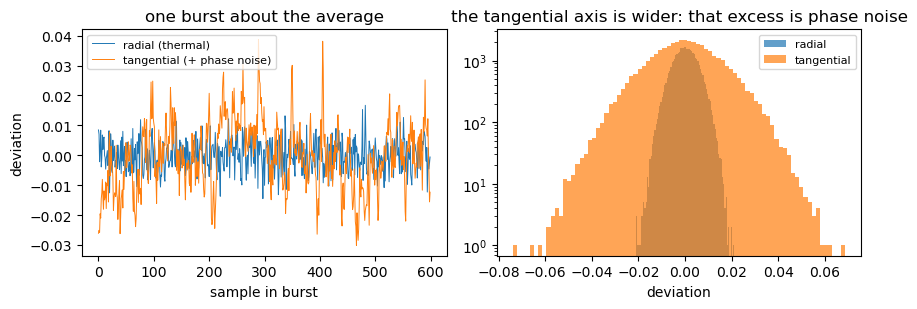

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(radial_deviation[0, data_window][:600], lw=0.7, label="radial (thermal)")
ax[0].plot(tangential_deviation[0, data_window][:600], lw=0.7, label="tangential (+ phase noise)")
ax[0].set_xlabel("sample in burst"); ax[0].set_ylabel("deviation")
ax[0].legend(fontsize=8); ax[0].set_title("one burst about the average")

ax[1].hist(radial_deviation[:, data_window].ravel(), bins=80, alpha=0.7, label="radial")
ax[1].hist(tangential_deviation[:, data_window].ravel(), bins=80, alpha=0.7, label="tangential")
ax[1].set_yscale("log"); ax[1].set_xlabel("deviation"); ax[1].legend(fontsize=8)
ax[1].set_title("the tangential axis is wider: that excess is phase noise")
fig.tight_layout()

## 9. Phase noise

Subtract the radial (thermal) power from the tangential power and what is left
is the phase contribution.

The recovered figure is about **half** the generator's `pn_tangential_deg`
label, and the ratio is stable across seeds — the two are not the same
quantity. The label is the generator's own constellation-domain
parameterisation, applied at symbol rate before the receive filter; the
estimate here is the sample-rate tangential excess after it. The estimator is
validated by the section above instead: the radial half of the same
decomposition recovers the injected SNR to well under a decibel, which it
could not do if the split were wrong.

In [13]:
phase_excess_power = max(tangential_power - radial_power, 0.0)
phase_noise_deg = np.degrees(np.sqrt(phase_excess_power / signal_power))

print(f"tangential excess  {phase_noise_deg:.4f} deg rms")
print(f"generator label    {injected_values['pn_tangential_deg']:.4f} deg "
      f"(ratio {phase_noise_deg / injected_values['pn_tangential_deg']:.2f})")

tangential excess  0.7673 deg rms
generator label    1.5000 deg (ratio 0.51)


## 10. TX LO leakage: where you measure decides whether you can

Leakage is a constant tone at the transmit LO, so in the received baseband it
sits at the carrier offset. The obvious move is to project the aligned burst
average onto that tone.

It fails, and the reason is the useful part. Every burst in a run carries the
**same symbols**, and a fixed symbol sequence has its own non-zero mean — about
$-27$ dBc here. Averaging bursts cannot reduce a term that is identical in
every burst, and the tone sits only ~650 Hz from it, far inside the 1 kHz
resolution of a 1 ms window. So the projection returns the sequence's DC.

Below: the injected level is swept over 50 dB and the estimate barely moves.

In [14]:
def lo_leakage_dbc(aligned_average, offset_hz):
    tone = np.exp(-2j * np.pi * offset_hz * sample_index / SAMPLE_RATE)
    amplitude = np.abs(np.mean(aligned_average[data_window] * tone[data_window]))
    reference = np.sqrt(np.mean(np.abs(aligned_average[data_window]) ** 2))
    return 20 * np.log10(amplitude / reference)


def align_and_average(received, n_bursts):
    aligned = []
    for start in burst_starts[:n_bursts]:
        burst = received[start:start + BURST_LENGTH].astype(np.complex128)
        offset_hz = carrier_offset_hz(burst[data_window])
        derotated = burst * np.exp(-2j * np.pi * offset_hz * sample_index / SAMPLE_RATE)
        timed = shift_samples(derotated, -residual_delay_samples(derotated, reference_burst))
        phase = np.angle(np.vdot(transmitted_preamble, timed[:PREAMBLE_END]))
        aligned.append(timed * np.exp(-1j * phase))
    return unit_power(np.mean(aligned, 0)), offset_hz


sequence_dc_dbc = 20 * np.log10(
    abs(np.mean(transmitted_unit[data_window]))
    / np.sqrt(np.mean(np.abs(transmitted_unit[data_window]) ** 2)))

print(f"the transmitted sequence's own DC      {sequence_dc_dbc:6.2f} dBc")
print(f"1/sqrt(samples), if it averaged down   {-10 * np.log10(DATA_END - DATA_START):6.2f} dBc")
print()
print("injected   estimated")
for level_dbc in (-60.0, -35.0, -20.0, -10.0):
    loud_profile = dict(device_profile)
    loud_profile["lo_leak_dbc"] = level_dbc
    loud_spec = copy.deepcopy(variation_spec)
    loud_spec["lo_leak_dbc"] = {"kind": "fixed"}
    _, loud_received, _ = generator.synth_run(
        loud_profile, loud_spec, np.random.default_rng(seed=0), {}, N_BURSTS)
    loud_average, loud_offset = align_and_average(loud_received, N_BURSTS)
    print(f"  {level_dbc:6.1f}     {lo_leakage_dbc(loud_average, loud_offset):6.2f} dBc")

the transmitted sequence's own DC      -26.54 dBc
1/sqrt(samples), if it averaged down   -36.99 dBc

injected   estimated


   -60.0     -26.58 dBc


   -35.0     -25.63 dBc


   -20.0     -21.68 dBc


   -10.0     -15.71 dBc


In [15]:
# averaging more bursts does not help: the floor is the sequence, not the noise
for n_bursts in (1, 2, 4, 8):
    average, offset = align_and_average(received_signal, n_bursts)
    print(f"{n_bursts} burst(s): {lo_leakage_dbc(average, offset):6.2f} dBc")
print(f"\ninjected {injected_values['lo_leak_dbc']:.2f} dBc -- none of these is measuring it")

1 burst(s): -26.79 dBc
2 burst(s): -26.77 dBc


4 burst(s): -26.77 dBc


8 burst(s): -26.76 dBc

injected -61.07 dBc -- none of these is measuring it


### Measure it in the null tail instead

The burst ends with 200 null symbols. The LO keeps running through them, so the
carrier feedthrough is still there while the modulation — and its DC — is not.
This is what `radio_characterise` does on the real captures, and it is why the
shipped profiles can quote $-60$ to $-85$ dBc.

Three things make it work. The tail has no sequence DC to hide behind. Each
tail collapses to one phasor, de-rotated at the run's carrier offset, and those
per-burst phasors form a series sampled at the burst rate — so a short FFT
across them resolves the tone from RX DC at 0 Hz instead of colliding with it,
and recovers the residual carrier-offset error at the same time. And the
integration is long: thousands of tail samples, so the floor drops as
$1/\sqrt{N}$ — this time legitimately, because thermal noise really is
independent from burst to burst.

The first 150 samples of the tail are skipped (matched-filter ring-down) and
the last 50 dropped before the next burst ramps.

In [16]:
TAIL_SKIP, TAIL_TRIM = 150, 50          # ring-down at the start, ramp at the end


def lo_leakage_from_tails(received, offset_hz, signal_rms, noise_rms):
    tail_phasors, n_tail_samples = [], 0
    for start in burst_starts:
        first = start + DATA_END + TAIL_SKIP
        last = start + BURST_LENGTH - TAIL_TRIM
        tail = received[first:last].astype(np.complex128)
        absolute_index = np.arange(first, last, dtype=float)
        tail_phasors.append(np.mean(tail * np.exp(-2j * np.pi * offset_hz
                                                  * absolute_index / SAMPLE_RATE)))
        n_tail_samples += len(tail)

    tail_phasors = np.asarray(tail_phasors)
    burst_rate = SAMPLE_RATE / generator.BURST_SPACING
    fft_size = 1 << int(np.ceil(np.log2(4 * len(tail_phasors))))
    spectrum = np.abs(np.fft.fft(tail_phasors, n=fft_size)) / len(tail_phasors)

    # search +-5 Hz for the residual carrier-offset error
    max_bin = max(1, int(round(5.0 / (burst_rate / fft_size))))
    search_bins = np.r_[0:max_bin + 1, fft_size - max_bin:fft_size]
    peak_bin = search_bins[int(np.argmax(spectrum[search_bins]))]

    coherent_floor = noise_rms / np.sqrt(n_tail_samples)
    return (20 * np.log10(spectrum[peak_bin] / signal_rms),
            20 * np.log10(coherent_floor / signal_rms), n_tail_samples)


mean_offset_hz = float(np.mean(per_burst_offset_hz))
signal_rms = 1.0                     # everything below is relative to this
noise_rms = signal_rms * 10 ** (-injected_values["snr_db"] / 20)


def scaled_to_unit_signal(received):
    """Scale a raw capture so one burst's data portion has unit rms, which is
    what the dBc references below are relative to."""
    reference_slice = slice(burst_starts[1] + DATA_START, burst_starts[1] + DATA_END)
    data_rms = np.sqrt(np.mean(np.abs(received[reference_slice]) ** 2))
    return received.astype(np.complex128) / data_rms


estimate, floor, n_samples = lo_leakage_from_tails(
    scaled_to_unit_signal(received_signal), mean_offset_hz, signal_rms, noise_rms)

print(f"estimated {estimate:7.2f} dBc")
print(f"injected  {injected_values['lo_leak_dbc']:7.2f} dBc")
print(f"floor     {floor:7.2f} dBc over {n_samples} tail samples")

estimated  -62.50 dBc
injected   -61.07 dBc
floor      -80.08 dBc over 6400 tail samples


In [17]:
print("injected   estimated   (floor %.1f dBc)" % floor)
for level_dbc in (-70.0, -60.0, -45.0, -30.0):
    swept_profile = dict(device_profile)
    swept_profile["lo_leak_dbc"] = level_dbc
    swept_spec = copy.deepcopy(variation_spec)
    swept_spec["lo_leak_dbc"] = {"kind": "fixed"}
    _, swept_received, swept_truth = generator.synth_run(
        swept_profile, swept_spec, np.random.default_rng(seed=0), {}, N_BURSTS)
    got, _, _ = lo_leakage_from_tails(scaled_to_unit_signal(swept_received),
                                      mean_offset_hz, signal_rms, noise_rms)
    print(f"  {swept_truth['lo_leak_dbc']:6.1f}     {got:7.2f} dBc")

injected   estimated   (floor -80.1 dBc)
   -70.0      -77.56 dBc
   -60.0      -62.40 dBc
   -45.0      -45.43 dBc
   -30.0      -30.17 dBc


A few tenths of a decibel while the tone is comfortably above the floor, and
biased upward as it approaches it — the $-70$ dBc row sits only 10 dB clear and
reads several decibels high. `radio_characterise` stores
`lo_leakage_floor_dbc` next to every estimate for exactly this reason, and
takes the per-radio value as a median over runs whose LO was not drifting
enough to smear the line.

The general point is not about leakage. The same quantity was unmeasurable in
one part of the burst and straightforward in another, with no change to the
hardware or the estimator's arithmetic — only to where it looked.

## 11. What the round trips showed

| quantity | estimator | recovered vs injected |
|---|---|---|
| carrier offset | $x^4$ peak, parabolic interpolation | 0.005 ppm on 1.5 ppm |
| sampling clock | slope of the unwrapped per-burst delays | ~5% in magnitude, sign inverted |
| PA cubic $b$ | joint least squares, PA before ISI | ~0.1% |
| ISI taps | same fit | ~10%, limited by clock resampling |
| IQ imbalance | $2\times2$ map vs the fitted model | signs inverted; magnitudes to a few % |
| thermal SNR | radial deviation $\times 2$ | under 1 dB |
| phase noise | tangential excess over radial | 0.5x the generator's label (different definition) |
| LO leakage, data portion | tone projection | fails: returns the sequence's own DC |
| LO leakage, null tail | per-tail phasors, FFT across bursts | 1.4 dB, tenths of a dB well above the floor |

Three rules earned the hard way, each of which caught a real error here:

1. **Round-trip every estimator, in sign and in magnitude.** The IQ estimator
   is accurate and inverted. No magnitude-domain metric would show it, and a
   profile built from it feeds the wrong sign straight back into the generator.
2. **Compute the floor, and check what sets it.** An estimator always returns
   something. In the data portion the leakage estimate is the transmit
   sequence's own DC, and sweeping the injected level over 50 dB barely moves
   it. The obvious $1/\sqrt{N}$ did not apply there, because averaging bursts
   cannot reduce a term identical in every burst. In the null tail, where the
   modulation is absent, $1/\sqrt{N}$ is true and the same quantity is easy.
3. **Reference the model, not the decisions.** Any distortion the reference
   does not contain is charged to whatever you are estimating — nearly three
   degrees of it in the IQ section.

A fourth, from the fitting section: a design that lowers the residual has not
necessarily improved recovery. Both were checked against truth here because
truth was available, which on a real capture it is not.